# S&P 500 Clustering Pipeline
Single notebook with feature-case tuning, **k selection**, temporal stability evaluation (train → validation → test), and **mean + std aggregation** per stock.

## 1. Setup

In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

## 2. Load Data

In [44]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"

df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).copy()

print("Min date:", df['Date'].min())
print("Max date:", df['Date'].max())
print("Rows:", len(df))
print("Stocks:", df['Symbol'].nunique())
df.head()

Min date: 2021-03-22 00:00:00
Max date: 2026-03-20 00:00:00
Rows: 626169
Stocks: 503


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight
11304,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005
11305,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005
11306,2021-03-24,118.022998,118.834813,116.689291,116.785934,1477500,A,Agilent Technologies,Health Care,0.0005
11307,2021-03-25,116.805284,118.225969,115.858159,117.810394,967300,A,Agilent Technologies,Health Care,0.0005
11308,2021-03-26,118.428900,121.492548,117.936008,121.424896,1441900,A,Agilent Technologies,Health Care,0.0005


### Overall Sector Stock Count and Weights (Full Dataset)

This table uses the **original loaded dataset** (`df`), before any splits or clustering, and summarizes:

- the number of distinct companies in each sector;
- the total index weight of each sector.

In [45]:
# Simple sector table from the original dataset (no clustering, no splits)
if "Sector" in df.columns:
    sector_col = "Sector"
elif "GICS Sector" in df.columns:
    sector_col = "GICS Sector"
else:
    sector_col = None

# Try to locate a weight column (fall back to equal-weight if absent)
possible_weight_cols = ["Weight", "Index Weight", "Index_Weight", "IndexWeight"]
weight_col = None
for col in possible_weight_cols:
    if col in df.columns:
        weight_col = col
        break

if sector_col is None:
    print("No sector column found (expected 'Sector' or 'GICS Sector').")
else:
    # One row per company with a single weight
    cols = ["Symbol", sector_col]
    if weight_col is not None:
        cols.append(weight_col)

    symbol_level_full = (
        df[cols]
        .dropna(subset=[sector_col])
        .drop_duplicates(subset=["Symbol"])
)

    if weight_col is None:
        # Equal-weighted if no explicit weight column
        symbol_level_full["_weight"] = 1.0
        weight_col_use = "_weight"
    else:
        weight_col_use = weight_col

    sector_summary_full = (
        symbol_level_full
        .groupby(sector_col)
        .agg(
            Company_count=("Symbol", "nunique"),
            Total_weight=(weight_col_use, "sum"),
        )
        .reset_index()
        .rename(columns={sector_col: "Sector"})
    )

    # Sort by total weight descending
    sector_summary_full = sector_summary_full.sort_values("Total_weight", ascending=False).reset_index(drop=True)

    display(sector_summary_full)

,Sector,Company_count,Total_weight
0,Information Technology,71,0.3197
1,Financials,76,0.1273
2,Communication Services,23,0.1150
3,Consumer Discretionary,48,0.1033
4,Health Care,60,0.0917
5,Industrials,79,0.0862
6,Consumer Staples,36,0.0582
7,Energy,22,0.0376
8,Utilities,31,0.0239
9,Materials,26,0.0189


## 3. Feature Engineering (Full Timeline)


In [46]:
def create_features(df):
    # Sort first so lag/rolling operations follow true chronological order per symbol
    df = df.sort_values(['Symbol', 'Date']).copy()
    df['log_close'] = np.log(df['Close'])

    # Returns
    df['logret_1'] = df.groupby('Symbol')['log_close'].diff(1)
    df['logret_5'] = df.groupby('Symbol')['log_close'].diff(5)
    df['logret_21'] = df.groupby('Symbol')['log_close'].diff(21)

    # Matched volatility windows
    df['logvol_1'] = df.groupby('Symbol')['logret_1'].rolling(2).std().reset_index(level=0, drop=True)
    df['logvol_5'] = df.groupby('Symbol')['logret_1'].rolling(5).std().reset_index(level=0, drop=True)
    df['logvol_21'] = df.groupby('Symbol')['logret_1'].rolling(21).std().reset_index(level=0, drop=True)

    # Volume features
    df['log_volume'] = np.log(df['Volume'].clip(lower=1))

    # Keep original single-horizon volume change for appendix comparison
    df['vol_chg'] = df.groupby('Symbol')['log_volume'].diff(1)

    # Main pipeline uses horizon-matched volume-change features
    df['vol_chg_1'] = df.groupby('Symbol')['log_volume'].diff(1)
    df['vol_chg_5'] = df.groupby('Symbol')['log_volume'].diff(5)
    df['vol_chg_21'] = df.groupby('Symbol')['log_volume'].diff(21)

    return df

# split FIRST using your exact dates
train = df[(df['Date'] >= '2021-03-22') & (df['Date'] <= '2024-03-21')].copy()
val   = df[(df['Date'] >= '2024-03-22') & (df['Date'] <= '2025-03-21')].copy()
test  = df[(df['Date'] >= '2025-03-22') & (df['Date'] <= '2026-03-21')].copy()

# THEN feature engineering
train = create_features(train)
val   = create_features(val)
test  = create_features(test)

print("Train:", len(train))
print("Val:", len(val))
print("Test:", len(test))

Train: 375299
Val: 125271
Test: 125599


## 4. Time-based Split (3y / 1y / 1y)


## 5. Keep Only Stocks Available in All 3 Splits


In [47]:
common_symbols = (
    set(train['Symbol'].unique())
    & set(val['Symbol'].unique())
    & set(test['Symbol'].unique())
)

train = train[train['Symbol'].isin(common_symbols)].copy()
val   = val[val['Symbol'].isin(common_symbols)].copy()
test  = test[test['Symbol'].isin(common_symbols)].copy()

print('Common stocks:', len(common_symbols))
print('Train stocks:', train['Symbol'].nunique())
print('Validation stocks:', val['Symbol'].nunique())
print('Test stocks:', test['Symbol'].nunique())

train

Common stocks: 499
Train stocks: 499
Validation stocks: 499
Test stocks: 499


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight,...,logret_5,logret_21,logvol_1,logvol_5,logvol_21,log_volume,vol_chg,vol_chg_1,vol_chg_5,vol_chg_21
11304,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005,...,NaN,NaN,NaN,NaN,NaN,14.388127,NaN,NaN,NaN,NaN
11305,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005,...,NaN,NaN,NaN,NaN,NaN,14.106911,-0.281216,-0.281216,NaN,NaN
11306,2021-03-24,118.022998,118.834813,116.689291,116.785934,1477500,A,Agilent Technologies,Health Care,0.0005,...,NaN,NaN,0.002747,NaN,NaN,14.205862,0.098951,0.098951,NaN,NaN
11307,2021-03-25,116.805284,118.225969,115.858159,117.810394,967300,A,Agilent Technologies,Health Care,0.0005,...,NaN,NaN,0.012815,NaN,NaN,13.782264,-0.423598,-0.423598,NaN,NaN
11308,2021-03-26,118.428900,121.492548,117.936008,121.424896,1441900,A,Agilent Technologies,Health Care,0.0005,...,NaN,NaN,0.015193,NaN,NaN,14.181472,0.399208,0.399208,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625664,2024-03-15,169.480485,171.167679,167.364175,168.300430,3399500,ZTS,Zoetis,Health Care,0.0008,...,-0.054082,-0.064567,0.004145,0.012876,0.017850,15.039139,-0.637750,-0.637750,-0.650939,0.220500
625665,2024-03-18,169.441477,169.968110,166.193863,166.466934,4955000,ZTS,Zoetis,Health Care,0.0008,...,-0.072311,-0.105331,0.002398,0.008207,0.016239,15.415908,0.376769,0.376769,0.381486,0.597709
625666,2024-03-19,167.412947,169.207419,166.057337,168.680786,3624000,ZTS,Zoetis,Health Care,0.0008,...,-0.047369,-0.085454,0.017087,0.015028,0.016710,15.103089,-0.312819,-0.312819,0.332683,0.617853
625667,2024-03-20,168.378440,168.827066,165.150335,166.759521,3697300,ZTS,Zoetis,Health Care,0.0008,...,-0.030185,-0.087094,0.017442,0.010965,0.016742,15.123113,0.020024,0.020024,-0.475351,0.390193


## Sector Stock Count and Weights (Train)


This summarizes, for the **training** split:


- how many distinct stocks are in each sector;
- the total index weight of that sector (using one weight per stock);
- and the sector's share of total training weight.

In [48]:
# Sector stock count and weights for training data
if "Sector" in train.columns:
    sector_col = "Sector"
elif "GICS Sector" in train.columns:
    sector_col = "GICS Sector"
else:
    sector_col = None

# Try to locate a weight column (fall back to equal-weight if absent)
possible_weight_cols = ["Weight", "Index Weight", "Index_Weight", "IndexWeight"]
weight_col = None
for col in possible_weight_cols:
    if col in train.columns:
        weight_col = col
        break

if sector_col is None:
    print("No sector column found (expected 'Sector' or 'GICS Sector').")
else:
    # One row per stock with a single weight
    cols = ["Symbol", sector_col]
    if weight_col is not None:
        cols.append(weight_col)

    symbol_level = (
        train[cols]
        .dropna(subset=[sector_col])
        .drop_duplicates(subset=["Symbol"])
)

    if weight_col is None:
        # Equal-weighted if no explicit weight column
        symbol_level["_weight"] = 1.0
        weight_col_use = "_weight"
    else:
        weight_col_use = weight_col

    sector_summary = (
        symbol_level
        .groupby(sector_col)
        .agg(
            Company_count=("Symbol", "nunique"),
            Total_weight=(weight_col_use, "sum"),
        )
        .reset_index()
        .rename(columns={sector_col: "Sector"})
    )

    # Sort by total weight descending for readability
    sector_summary = sector_summary.sort_values("Total_weight", ascending=False).reset_index(drop=True)

    display(sector_summary)

,Sector,Company_count,Total_weight
0,Information Technology,69,0.3175
1,Financials,76,0.1273
2,Communication Services,23,0.1150
3,Consumer Discretionary,48,0.1033
4,Health Care,59,0.0915
5,Industrials,78,0.0823
6,Consumer Staples,36,0.0582
7,Energy,22,0.0376
8,Utilities,31,0.0239
9,Materials,26,0.0189


### Example Cyclical vs Defensive Stocks

This cell selects **3 cyclical** and **3 defensive** stocks from the S&P 500 universe based on their sector, and shows them in a small table.

In [73]:
# Pick 3 cyclical and 3 defensive stocks based on actual price volatility
import numpy as np

# Decide which column holds the sector information
if "Sector" in df.columns:
    sector_col = "Sector"
elif "GICS Sector" in df.columns:
    sector_col = "GICS Sector"
else:
    sector_col = None

if sector_col is None:
    print("No sector column found (expected 'Sector' or 'GICS Sector').")
else:
    # Simple mapping from sectors to cyclical / defensive buckets
    cyclical_sectors = [
        "Consumer Discretionary",
        "Industrials",
        "Materials",
        "Financials",
        "Real Estate",
        "Information Technology",
        "Communication Services",
    ]
    defensive_sectors = [
        "Consumer Staples",
        "Health Care",
        "Utilities",
    ]

    # One row per stock with its sector
    symbol_sector = (
        df[["Symbol", sector_col]]
        .dropna()
        .drop_duplicates(subset=["Symbol"])
        .rename(columns={sector_col: "Sector"})
    )

    # Classify each stock as Cyclical / Defensive / Other
    symbol_sector["Category"] = np.where(
        symbol_sector["Sector"].isin(defensive_sectors),
        "Defensive",
        np.where(symbol_sector["Sector"].isin(cyclical_sectors), "Cyclical", "Other"),
    )

    # Use realized volatility of daily returns to pick jumpy vs steady stocks
    df_sorted = df.sort_values(["Symbol", "Date"]).copy()
    df_sorted["daily_ret"] = df_sorted.groupby("Symbol")["Close"].pct_change()

    # Require a minimum number of observations so we don't pick stocks with only a few dates
    stats_per_symbol = (
        df_sorted.groupby("Symbol")["daily_ret"]
        .agg(n_obs="count", volatility="std")
        .reset_index()
        .dropna(subset=["volatility"])
    )
    min_obs = 500  # minimum daily-return observations to be eligible
    vol_per_symbol = stats_per_symbol[stats_per_symbol["n_obs"] >= min_obs][["Symbol", "volatility"]]

    symbol_sector = symbol_sector.merge(vol_per_symbol, on="Symbol", how="inner")

    cyclical_candidates = symbol_sector[symbol_sector["Category"] == "Cyclical"].copy()
    defensive_candidates = symbol_sector[symbol_sector["Category"] == "Defensive"].copy()

    if len(cyclical_candidates) < 3 or len(defensive_candidates) < 3:
        print("Not enough stocks in each group (with sufficient history) to select 3 high-vol cyclical and 3 low-vol defensive stocks.")
    else:
        # Cyclical: pick the most volatile (jumpy prices)
        sample_cyclical = (
            cyclical_candidates
            .sort_values("volatility", ascending=False)
            .head(3)
        )

        # Defensive: pick the least volatile (steady prices)
        sample_defensive = (
            defensive_candidates
            .sort_values("volatility", ascending=True)
            .head(3)
        )

        example_stocks = (
            pd.concat([sample_cyclical, sample_defensive], ignore_index=True)
            .sort_values(["Category", "Sector", "Symbol"])
            .reset_index(drop=True)
        )

        # Show which stocks were chosen and how volatile they are (with sufficient history)
        display(example_stocks[["Symbol", "Sector", "Category", "volatility"]])

,Symbol,Sector,Category,volatility
0,CVNA,Consumer Discretionary,Cyclical,0.069986
1,COIN,Financials,Cyclical,0.054197
2,SMCI,Information Technology,Cyclical,0.052506
3,KO,Consumer Staples,Defensive,0.009949
4,PG,Consumer Staples,Defensive,0.011021
5,JNJ,Health Care,Defensive,0.010506


### Price Movement for Example Stocks (June & December)

This cell shows **June and December** price points for the 3 cyclical and 3 defensive example stocks (one price per month per year).

In [74]:
# Show June and December price points for the 3 cyclical and 3 defensive example stocks

# This assumes the previous cell (example_stocks) has been run
if "example_stocks" not in globals():
    print("Please run the cell above (Example Cyclical vs Defensive Stocks) first.")
else:
    selected_symbols = example_stocks["Symbol"].unique()
    price_subset = (
        df[df["Symbol"].isin(selected_symbols)]
        .copy()
        .sort_values(["Symbol", "Date"])
    )

    # Extract year and month
    price_subset["year"] = price_subset["Date"].dt.year
    price_subset["month"] = price_subset["Date"].dt.month

    # Keep only June (6) and December (12) observations
    price_jun_dec = price_subset[price_subset["month"].isin([6, 12])].copy()

    # For each stock, year, and month, keep the last available trading date
    price_jun_dec = (
        price_jun_dec
        .groupby(["Symbol", "year", "month"], group_keys=False)
        .tail(1)
    )

    # Compute simple return for each stock across these points
    price_jun_dec["Pct_change"] = (
        price_jun_dec.groupby("Symbol")["Close"].pct_change()
    )

    # Neater ordering
    price_jun_dec = price_jun_dec[["Symbol", "Date", "Close", "Pct_change"]]
    price_jun_dec = price_jun_dec.sort_values(["Symbol", "Date"]).reset_index(drop=True)

    display(price_jun_dec)

,Symbol,Date,Close,Pct_change
0,COIN,2021-06-30,253.300003,NaN
1,COIN,2021-12-31,252.369995,-0.003672
2,COIN,2022-06-30,47.020000,-0.813686
3,COIN,2022-12-30,35.389999,-0.247342
4,COIN,2023-06-30,71.550003,1.021758
5,COIN,2023-12-29,173.919998,1.430748
6,COIN,2024-06-28,222.229996,0.277771
7,COIN,2024-12-31,248.300003,0.117311
8,COIN,2025-06-30,350.489990,0.411559
9,COIN,2025-12-31,226.139999,-0.354789


## 6. Define Feature Cases

In [51]:
FEATURE_CASES = {
    "case_1": ['logret_1', 'logvol_1', 'vol_chg_1'],
    "case_2": ['logret_5', 'logvol_5', 'vol_chg_5'],
    "case_3": ['logret_21', 'logvol_21', 'vol_chg_21']
}

FEATURE_CASES


{'case_1': ['logret_1', 'logvol_1', 'vol_chg_1'],
 'case_2': ['logret_5', 'logvol_5', 'vol_chg_5'],
 'case_3': ['logret_21', 'logvol_21', 'vol_chg_21']}

## 7. Aggregate Daily Features to One Vector Per Stock
Each stock is represented by:
- the **mean** of every selected feature
- the **standard deviation** of time-varying features

All selected features contribute both mean and standard deviation to the stock-level summary.

In [52]:
def aggregate_features(df, feature_cols):
    # Mean of all selected features
    agg_mean = df.groupby('Symbol')[feature_cols].mean()
    # Standard deviation only for time-varying features
    cols_for_std = list(feature_cols)
    agg_std = df.groupby('Symbol')[cols_for_std].std()
    agg_std.columns = [f"{col}_std" for col in agg_std.columns]

    # Combine mean + std
    X = pd.concat([agg_mean, agg_std], axis=1)

    return X.dropna()

## 8. KMeans Helper Functions

In [53]:
def fit_kmeans(X, k):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    return model, scaler, labels, score, X_scaled

def apply_kmeans(X, model, scaler):
    X_scaled = scaler.transform(X)
    labels = model.predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    return labels, score, X_scaled

def evaluate_k_range(X, k_range=range(2, 9)):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    rows = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        inertia = model.inertia_

        rows.append({
            "k": k,
            "silhouette": sil,
            "inertia": inertia
        })

    return pd.DataFrame(rows), X_scaled

## 9. Compare Feature Cases on Training Set
For each feature case, search over candidate `k` values and keep the best silhouette score.

In [54]:
feature_case_results = []

for case_name, feature_cols in FEATURE_CASES.items():
    X_train_case = aggregate_features(train, feature_cols)
    k_results_case, _ = evaluate_k_range(X_train_case, k_range=range(2, 9))

    best_idx = k_results_case['silhouette'].idxmax()
    best_k_case = int(k_results_case.loc[best_idx, 'k'])
    best_sil_case = float(k_results_case.loc[best_idx, 'silhouette'])

    feature_case_results.append({
        "case": case_name,
        "features": ", ".join(feature_cols),
        "n_stocks": len(X_train_case),
        "aggregated_feature_count": X_train_case.shape[1],
        "best_k": best_k_case,
        "best_train_silhouette": best_sil_case
    })

feature_case_results_df = (
    pd.DataFrame(feature_case_results)
    .sort_values("best_train_silhouette", ascending=False)
    .reset_index(drop=True)
)

feature_case_results_df

,case,features,n_stocks,aggregated_feature_count,best_k,best_train_silhouette
0,case_3,"logret_21, logvol_21, vol_chg_21",499,6,2,0.569157
1,case_2,"logret_5, logvol_5, vol_chg_5",499,6,2,0.556215
2,case_1,"logret_1, logvol_1, vol_chg_1",499,6,2,0.527696


## 10. Select Best Feature Case

In [55]:
best_case = feature_case_results_df.loc[0, 'case']
best_features = FEATURE_CASES[best_case]

print("Best feature case:", best_case)
print("Selected raw features:", best_features)

Best feature case: case_3
Selected raw features: ['logret_21', 'logvol_21', 'vol_chg_21']


## 11. Build Final Training Matrix

In [57]:
X_train = aggregate_features(train, best_features)

print("Training matrix shape:", X_train.shape)
print("Aggregated columns:")
print(list(X_train.columns))

X_train.head()

Training matrix shape: (499, 6)
Aggregated columns:
['logret_21', 'logvol_21', 'vol_chg_21', 'logret_21_std', 'logvol_21_std', 'vol_chg_21_std']


,logret_21,logvol_21,vol_chg_21,logret_21_std,logvol_21_std,vol_chg_21_std
Symbol,,,,,,
A,0.003473,0.017097,0.009891,0.078903,0.005214,0.499563
AAPL,0.009726,0.015948,-0.008466,0.074409,0.005772,0.366824
ABBV,0.018183,0.012049,-0.003392,0.062869,0.003770,0.464716
ABNB,-0.003440,0.029775,0.010216,0.130475,0.009681,0.677540
ABT,0.000751,0.013496,-0.000386,0.060589,0.004314,0.463441


## 12. Select the Number of Clusters (k)
Use **silhouette score** as the main criterion and **inertia** as supporting evidence.

In [58]:
k_results, _ = evaluate_k_range(X_train, k_range=range(2, 9))
k_results

,k,silhouette,inertia
0,2,0.569157,2190.544366
1,3,0.553032,1763.706271
2,4,0.326679,1433.046063
3,5,0.331376,1241.416586
4,6,0.326169,1066.573046
5,7,0.331625,915.733049
6,8,0.222712,827.978796


## 13. Plot Silhouette and Elbow Curves

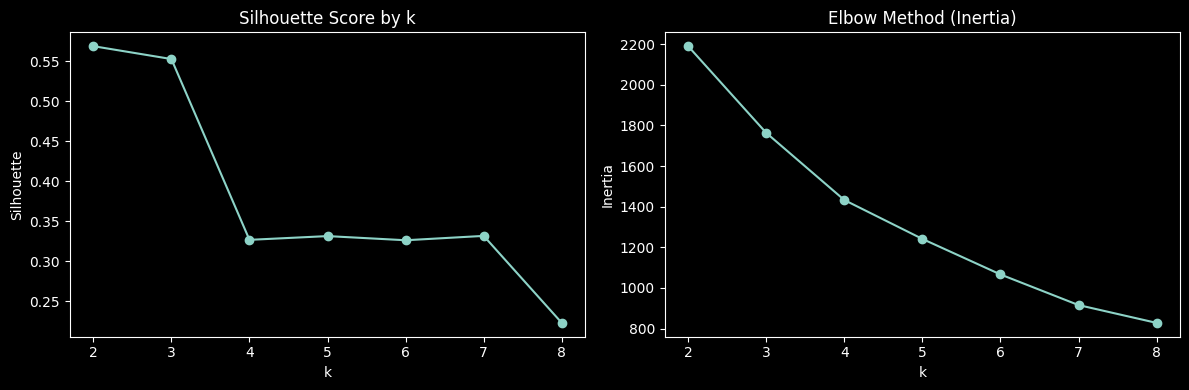

In [75]:
with plt.style.context('dark_background'):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(k_results['k'], k_results['silhouette'], marker='o')
    plt.title("Silhouette Score by k")
    plt.xlabel("k")
    plt.ylabel("Silhouette")

    plt.subplot(1, 2, 2)
    plt.plot(k_results['k'], k_results['inertia'], marker='o')
    plt.title("Elbow Method (Inertia)")
    plt.xlabel("k")
    plt.ylabel("Inertia")

    plt.tight_layout()
    plt.show()

## 14. Choose Best k

In [60]:
best_k = int(k_results.loc[k_results['silhouette'].idxmax(), 'k'])
print("Selected k:", best_k)

Selected k: 2


## 15. Fit Final Clustering on Train

In [61]:
model, scaler, train_labels, train_score, X_train_scaled = fit_kmeans(X_train, k=best_k)

train_clusters = pd.DataFrame({
    "Symbol": X_train.index,
    "Cluster_train": train_labels
})

print("Train silhouette:", round(train_score, 4))
train_clusters.head()

Train silhouette: 0.5692


,Symbol,Cluster_train
0,A,0
1,AAPL,0
2,ABBV,0
3,ABNB,1
4,ABT,0


In [ ]:
from scipy.spatial.distance import cdist

# distance to centroids (using scaled data)
dist_matrix = cdist(X_train_scaled, model.cluster_centers_)

# distance to assigned centroid
assigned_dist = [
    dist_matrix[i, label] for i, label in enumerate(train_labels)
]

# attach to dataframe
X_train_with_labels = X_train.copy()
X_train_with_labels['cluster'] = train_labels
X_train_with_labels['distance_to_centroid'] = assigned_dist

# get 2 closest stocks per cluster
closest_stocks = (
    X_train_with_labels
    .sort_values(['cluster', 'distance_to_centroid'])
    .groupby('cluster')
    .head(2)
 )

closest_stocks

## 16. Evaluate Cluster Stability on Validation

In [62]:
X_val = aggregate_features(val, best_features)

common_train_val = X_train.index.intersection(X_val.index)
X_val = X_val.loc[common_train_val]

val_labels, val_score, X_val_scaled = apply_kmeans(X_val, model, scaler)

val_clusters = pd.DataFrame({
    "Symbol": X_val.index,
    "Cluster_val": val_labels
})

print("Validation silhouette:", round(val_score, 4))
val_clusters.head()

Validation silhouette: 0.5258


,Symbol,Cluster_val
0,A,0
1,AAPL,0
2,ABBV,0
3,ABNB,0
4,ABT,0


## 17. Confirm Cluster Stability on Test

In [63]:
X_test = aggregate_features(test, best_features)

common_train_test = X_train.index.intersection(X_test.index)
X_test = X_test.loc[common_train_test]

test_labels, test_score, X_test_scaled = apply_kmeans(X_test, model, scaler)

test_clusters = pd.DataFrame({
    "Symbol": X_test.index,
    "Cluster_test": test_labels
})

print("Test silhouette:", round(test_score, 4))
test_clusters.head()

Test silhouette: 0.3748


,Symbol,Cluster_test
0,A,0
1,AAPL,0
2,ABBV,0
3,ABNB,0
4,ABT,0


## 18. Stability Summary

In [64]:
stability_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "silhouette": [train_score, val_score, test_score]
})

stability_summary

,split,silhouette
0,train,0.569157
1,validation,0.525816
2,test,0.374775


## 19. Same-Stock Cluster Consistency

In [65]:
train_val_compare = train_clusters.merge(val_clusters, on="Symbol", how="inner")
train_test_compare = train_clusters.merge(test_clusters, on="Symbol", how="inner")

train_val_consistency = (train_val_compare["Cluster_train"] == train_val_compare["Cluster_val"]).mean()
train_test_consistency = (train_test_compare["Cluster_train"] == train_test_compare["Cluster_test"]).mean()

print("Train vs Validation consistency:", round(train_val_consistency, 4))
print("Train vs Test consistency:", round(train_test_consistency, 4))

Train vs Validation consistency: 0.8818
Train vs Test consistency: 0.8577


## 20. Cluster Profiles on Training Set

In [66]:
train_profile = X_train.copy()
train_profile["Cluster"] = train_labels

cluster_profile = train_profile.groupby("Cluster").mean()
cluster_profile

,logret_21,logvol_21,vol_chg_21,logret_21_std,logvol_21_std,vol_chg_21_std
Cluster,,,,,,
0,0.006950,0.01694,0.003339,0.077722,0.005479,0.530765
1,-0.001103,0.03186,0.006831,0.153690,0.012880,0.683821


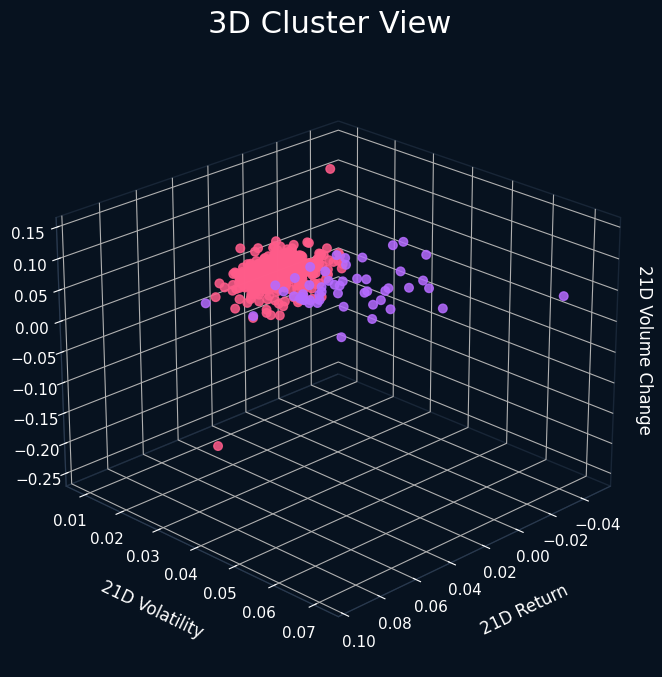

In [87]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# --- Theme ---
bg_color = "#07121f"
grid_color = "#2a3a4f"
text_color = "white"
cluster_colors = ["#ff5c8a", "#b56bff"]

fig = plt.figure(figsize=(8, 7), facecolor=bg_color)
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor(bg_color)

# Clean panes
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.xaxis.pane.set_edgecolor(grid_color)
ax.yaxis.pane.set_edgecolor(grid_color)
ax.zaxis.pane.set_edgecolor(grid_color)

ax.xaxis.line.set_color(grid_color)
ax.yaxis.line.set_color(grid_color)
ax.zaxis.line.set_color(grid_color)

unique_clusters = sorted(X_plot["cluster"].unique())

for i, cluster in enumerate(unique_clusters):
    subset = X_plot[X_plot["cluster"] == cluster]

    ax.scatter(
        subset[feature_cols[0]],
        subset[feature_cols[1]],
        subset[feature_cols[2]],
        color=cluster_colors[i % len(cluster_colors)],
        s=38,
        alpha=0.85
    )

ax.set_title("3D Cluster View", color=text_color, fontsize=22, pad=18)
ax.set_xlabel("21D Return", color=text_color, labelpad=14, fontsize=12)
ax.set_ylabel("21D Volatility", color=text_color, labelpad=14, fontsize=12)

# Remove default z-label
ax.set_zlabel("")

# Put custom z label on the right side
ax.text2D(1.0, 0.52, "21D Volume Change", transform=ax.transAxes,
          color=text_color, fontsize=12, rotation=-90, va="center", ha="left")

ax.tick_params(colors=text_color, labelsize=11)
ax.view_init(elev=24, azim=45)

plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.92)
plt.show()

## 21. PCA Visualization of Training Clusters

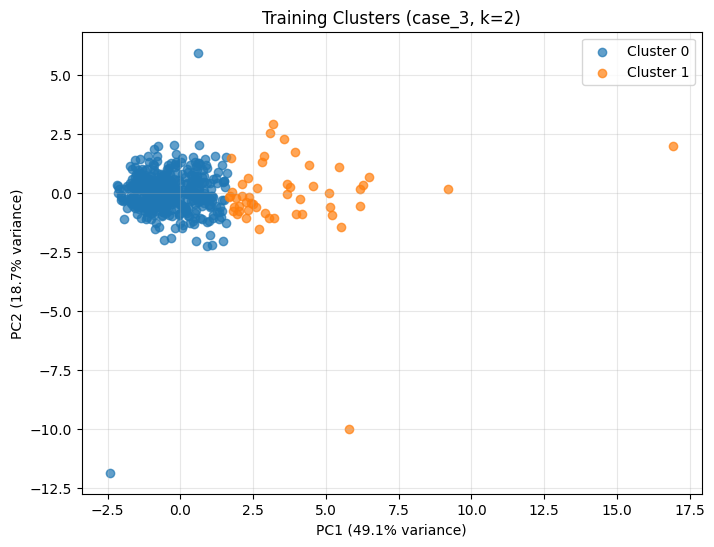

In [68]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Explained variance
explained = pca.explained_variance_ratio_

plt.figure(figsize=(8, 6))

# Plot each cluster separately for proper labels
for cluster in np.unique(train_labels):
    mask = train_labels == cluster
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.title(f"Training Clusters ({best_case}, k={best_k})")

# Better axis labels with variance explained
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [69]:
pd.Series(train_labels).value_counts()

0    448
1     51
Name: count, dtype: int64

## 22. Final Cluster Assignment Table

In [70]:
final_clusters = (
    train_clusters
    .merge(val_clusters, on="Symbol", how="left")
    .merge(test_clusters, on="Symbol", how="left")
)

final_clusters.head()

,Symbol,Cluster_train,Cluster_val,Cluster_test
0,A,0,0,0
1,AAPL,0,0,0
2,ABBV,0,0,0
3,ABNB,1,0,0
4,ABT,0,0,0


Sector counts by cluster


Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
cluster,,,,,,,,,,,
0,17,38,36,20,70,53,73,56,23,31,31
1,6,10,0,2,6,6,5,13,3,0,0


Sector percentages within each cluster


Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
cluster,,,,,,,,,,,
0,3.79,8.48,8.04,4.46,15.62,11.83,16.29,12.50,5.13,6.92,6.92
1,11.76,19.61,0.00,3.92,11.76,11.76,9.80,25.49,5.88,0.00,0.00


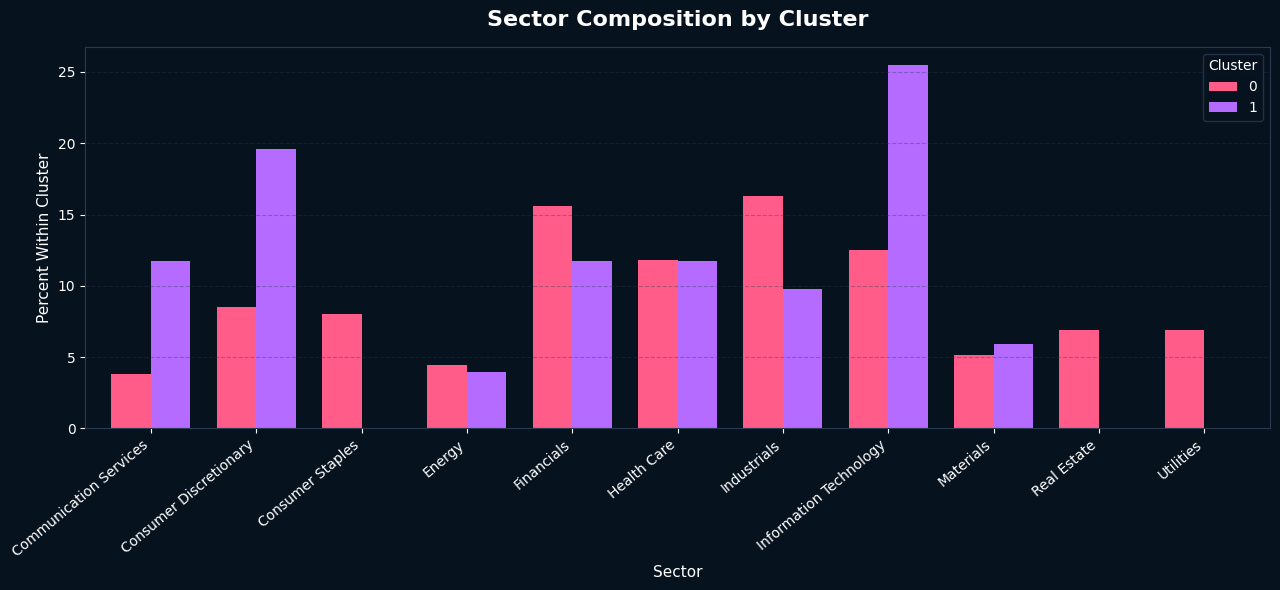

In [80]:
import matplotlib.pyplot as plt

# Sector concentration test: are clusters economically interpretable?
if "Sector" in train.columns:
    sector_col = "Sector"
elif "GICS Sector" in train.columns:
    sector_col = "GICS Sector"
else:
    sector_col = None

if sector_col is None:
    print("No sector column found (expected 'Sector' or 'GICS Sector').")
else:
    symbol_sector = (
        train[["Symbol", sector_col]]
        .dropna()
        .drop_duplicates(subset=["Symbol"])
        .rename(columns={sector_col: "Sector"})
    )

    # stock-level cluster assignments
    train_clusters = X_train_with_labels[["cluster"]].reset_index()

    cluster_sector = (
        train_clusters
        .merge(symbol_sector, on="Symbol", how="left")
        .dropna(subset=["Sector"])
    )

    sector_counts = pd.crosstab(cluster_sector["cluster"], cluster_sector["Sector"])
    sector_pct = sector_counts.div(sector_counts.sum(axis=1), axis=0) * 100

    print("Sector counts by cluster")
    display(sector_counts)

    print("Sector percentages within each cluster")
    display(sector_pct.round(2))

    # --- Slide style ---
    bg_color = "#07121f"      # dark navy
    grid_color = "#2a3a4f"    # subtle grid
    text_color = "white"

    # pink / purple palette
    cluster_colors = ["#ff5c8a", "#b56bff", "#ff8cc6", "#9d7bff"]

    fig, ax = plt.subplots(figsize=(13, 6), facecolor=bg_color)
    ax.set_facecolor(bg_color)

    sector_pct.T.plot(
        kind="bar",
        ax=ax,
        color=cluster_colors[:len(sector_pct.index)],
        width=0.75
    )

    ax.set_title(
        "Sector Composition by Cluster",
        color=text_color,
        fontsize=16,
        fontweight="bold",
        pad=15
    )
    ax.set_ylabel("Percent Within Cluster", color=text_color, fontsize=11)
    ax.set_xlabel("Sector", color=text_color, fontsize=11)

    ax.tick_params(axis="x", colors=text_color, rotation=40)
    ax.tick_params(axis="y", colors=text_color)

    # Clean spines
    for spine in ax.spines.values():
        spine.set_color(grid_color)

    # Subtle horizontal grid only
    ax.grid(axis="y", color=grid_color, linestyle="--", alpha=0.35)
    ax.grid(axis="x", visible=False)

    # Legend styling
    legend = ax.legend(
        title="Cluster",
        facecolor=bg_color,
        edgecolor=grid_color,
        fontsize=10
    )
    legend.get_title().set_color(text_color)
    for text in legend.get_texts():
        text.set_color(text_color)

    plt.xticks(ha="right")
    plt.tight_layout()
    plt.show()

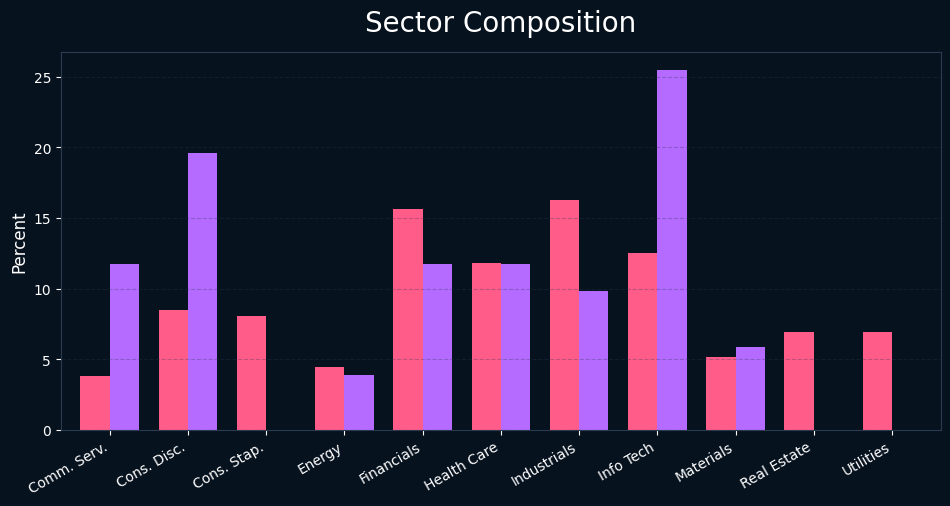

In [88]:
import matplotlib.pyplot as plt

# --- Theme ---
bg_color = "#07121f"
grid_color = "#2a3a4f"
text_color = "white"
cluster_colors = ["#ff5c8a", "#b56bff"]  # pink, purple

# Shorter sector names (IMPORTANT for slides)
sector_short = {
    "Communication Services": "Comm. Serv.",
    "Consumer Discretionary": "Cons. Disc.",
    "Consumer Staples": "Cons. Stap.",
    "Energy": "Energy",
    "Financials": "Financials",
    "Health Care": "Health Care",
    "Industrials": "Industrials",
    "Information Technology": "Info Tech",
    "Materials": "Materials",
    "Real Estate": "Real Estate",
    "Utilities": "Utilities"
}

sector_plot = sector_pct.T.copy()
sector_plot.index = [sector_short.get(x, x) for x in sector_plot.index]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6), facecolor=bg_color)
ax.set_facecolor(bg_color)

sector_plot.plot(
    kind="bar",
    ax=ax,
    color=cluster_colors[:len(sector_pct.index)],
    width=0.75
)

# Title
ax.set_title("Sector Composition", color=text_color, fontsize=20, pad=15)

# Axis labels
ax.set_ylabel("Percent", color=text_color, fontsize=12)
ax.set_xlabel("")  # cleaner → remove x label

# Ticks
ax.tick_params(axis="x", colors=text_color, rotation=30, labelsize=10)
ax.tick_params(axis="y", colors=text_color, labelsize=10)

# Clean spines
for spine in ax.spines.values():
    spine.set_color(grid_color)

# Subtle grid
ax.grid(axis="y", color=grid_color, linestyle="--", alpha=0.3)
ax.grid(axis="x", visible=False)

# Remove legend (you'll add manually on slide)
ax.legend().remove()

# Better spacing
plt.xticks(ha="right")
plt.subplots_adjust(left=0.10, right=0.98, bottom=0.25, top=0.88)

plt.show()

# Optional save
# plt.savefig("sector_chart.png", dpi=300, bbox_inches="tight", facecolor=bg_color)

# Appendix

In [72]:
# Appendix experiment: single-horizon volume-change feature (vol_chg) for comparison

# Use same full feature table and split windows
train_app = full_feat[(full_feat['Date'] >= '2021-03-22') & (full_feat['Date'] <= '2024-03-21')].copy()
val_app   = full_feat[(full_feat['Date'] >= '2024-03-22') & (full_feat['Date'] <= '2025-03-21')].copy()
test_app  = full_feat[(full_feat['Date'] >= '2025-03-22') & (full_feat['Date'] <= '2026-03-21')].copy()

common_symbols_app = (
    set(train_app['Symbol'].unique())
    & set(val_app['Symbol'].unique())
    & set(test_app['Symbol'].unique())
)

train_app = train_app[train_app['Symbol'].isin(common_symbols_app)].copy()
val_app   = val_app[val_app['Symbol'].isin(common_symbols_app)].copy()
test_app  = test_app[test_app['Symbol'].isin(common_symbols_app)].copy()

FEATURE_CASES_APP = {
    "case_1_app": ['logret_1', 'logvol_1', 'vol_chg'],
    "case_2_app": ['logret_5', 'logvol_5', 'vol_chg'],
    "case_3_app": ['logret_21', 'logvol_21', 'vol_chg']
}

# 1) Compare feature cases on training
feature_case_results_app = []
for case_name_app, feature_cols_app in FEATURE_CASES_APP.items():
    X_train_case_app = aggregate_features(train_app, feature_cols_app)
    k_results_case_app, _ = evaluate_k_range(X_train_case_app, k_range=range(2, 9))

    best_idx_app = k_results_case_app['silhouette'].idxmax()
    best_k_case_app = int(k_results_case_app.loc[best_idx_app, 'k'])
    best_sil_case_app = float(k_results_case_app.loc[best_idx_app, 'silhouette'])

    feature_case_results_app.append({
        "case": case_name_app,
        "features": ", ".join(feature_cols_app),
        "n_stocks": len(X_train_case_app),
        "aggregated_feature_count": X_train_case_app.shape[1],
        "best_k": best_k_case_app,
        "best_train_silhouette": best_sil_case_app
    })

feature_case_results_app_df = (
    pd.DataFrame(feature_case_results_app)
    .sort_values("best_train_silhouette", ascending=False)
    .reset_index(drop=True)
)

# 2) Select best case
best_case_app = feature_case_results_app_df.loc[0, 'case']
best_features_app = FEATURE_CASES_APP[best_case_app]

# 3) Build train matrix and choose k
X_train_app = aggregate_features(train_app, best_features_app)
k_results_app, _ = evaluate_k_range(X_train_app, k_range=range(2, 9))
best_k_app = int(k_results_app.loc[k_results_app['silhouette'].idxmax(), 'k'])

# 4) Fit final train clustering
model_app, scaler_app, train_labels_app, train_score_app, X_train_scaled_app = fit_kmeans(X_train_app, k=best_k_app)

train_clusters_app = pd.DataFrame({
    "Symbol": X_train_app.index,
    "Cluster_train_app": train_labels_app
})

# 5) Validation
X_val_app = aggregate_features(val_app, best_features_app)
common_train_val_app = X_train_app.index.intersection(X_val_app.index)
X_val_app = X_val_app.loc[common_train_val_app]

val_labels_app, val_score_app, X_val_scaled_app = apply_kmeans(X_val_app, model_app, scaler_app)
val_clusters_app = pd.DataFrame({
    "Symbol": X_val_app.index,
    "Cluster_val_app": val_labels_app
})

# 6) Test
X_test_app = aggregate_features(test_app, best_features_app)
common_train_test_app = X_train_app.index.intersection(X_test_app.index)
X_test_app = X_test_app.loc[common_train_test_app]

test_labels_app, test_score_app, X_test_scaled_app = apply_kmeans(X_test_app, model_app, scaler_app)
test_clusters_app = pd.DataFrame({
    "Symbol": X_test_app.index,
    "Cluster_test_app": test_labels_app
})

# 7) Stability summary
stability_summary_app = pd.DataFrame({
    "split": ["train_app", "validation_app", "test_app"],
    "silhouette": [train_score_app, val_score_app, test_score_app]
})

# 8) Same-stock consistency
train_val_compare_app = train_clusters_app.merge(val_clusters_app, on="Symbol", how="inner")
train_test_compare_app = train_clusters_app.merge(test_clusters_app, on="Symbol", how="inner")
train_val_consistency_app = (train_val_compare_app["Cluster_train_app"] == train_val_compare_app["Cluster_val_app"]).mean()
train_test_consistency_app = (train_test_compare_app["Cluster_train_app"] == train_test_compare_app["Cluster_test_app"]).mean()

# 9) Compare main pipeline vs appendix run
comparison_app = None
if all(v in globals() for v in ['best_case', 'best_k', 'train_score', 'val_score', 'test_score', 'train_val_consistency', 'train_test_consistency']):
    comparison_app = pd.DataFrame({
        "metric": [
            "best_case",
            "best_k",
            "train_silhouette",
            "validation_silhouette",
            "test_silhouette",
            "train_val_consistency",
            "train_test_consistency"
        ],
        "main_horizon_matched_volchg": [
            str(best_case),
            int(best_k),
            float(train_score),
            float(val_score),
            float(test_score),
            float(train_val_consistency),
            float(train_test_consistency)
        ],
        "appendix_single_volchg": [
            str(best_case_app),
            int(best_k_app),
            float(train_score_app),
            float(val_score_app),
            float(test_score_app),
            float(train_val_consistency_app),
            float(train_test_consistency_app)
        ]
    })

print('Appendix best case (single vol_chg):', best_case_app)
print('Appendix selected features:', best_features_app)
print('Appendix selected k:', best_k_app)
print('Appendix consistency (train-val, train-test):', round(train_val_consistency_app, 4), round(train_test_consistency_app, 4))

print()
print('Appendix feature case ranking:')
display(feature_case_results_app_df)

print()
print('Appendix stability summary:')
display(stability_summary_app)

if comparison_app is not None:
    print()
    print('Main (horizon-matched) vs Appendix (single vol_chg):')
    display(comparison_app)


NameError: name 'full_feat' is not defined

## 23. Cluster Profile Interpretation


In [ ]:
# Compare cluster means in raw units and z-scores (train split)
train_profile_detail = X_train.copy()
train_profile_detail["Cluster"] = train_labels

cluster_profile_mean = train_profile_detail.groupby("Cluster")[best_features].mean()
overall_mean = X_train[best_features].mean()
overall_std = X_train[best_features].std(ddof=0).replace(0, np.nan)
cluster_profile_z = (cluster_profile_mean - overall_mean) / overall_std

print("Cluster profile: means")
display(cluster_profile_mean.round(4))

print("Cluster profile: z-score vs full train universe")
display(cluster_profile_z.round(3))

if cluster_profile_mean.shape[0] == 2:
    abs_diff = (cluster_profile_mean.iloc[1] - cluster_profile_mean.iloc[0]).abs().sort_values(ascending=False)
    print("Most separating features (absolute mean diff between Cluster 0 and 1)")
    display(abs_diff.to_frame("abs_diff").round(4))


Cluster profile: means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0069,0.0169,0.0033
1,-0.0011,0.0319,0.0068


Cluster profile: z-score vs full train universe


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.062,-0.242,-0.020
1,-0.548,2.128,0.172


Most separating features (absolute mean diff between Cluster 0 and 1)


,abs_diff
logvol_21,0.0149
logret_21,0.0081
vol_chg_21,0.0035


## 24. Sector Composition by Cluster (Train)


## 25. Out-of-Sample Stability Diagnostics


Cluster share by split (%)


,train,validation,test
0,89.78,89.38,80.56
1,10.22,10.62,19.44


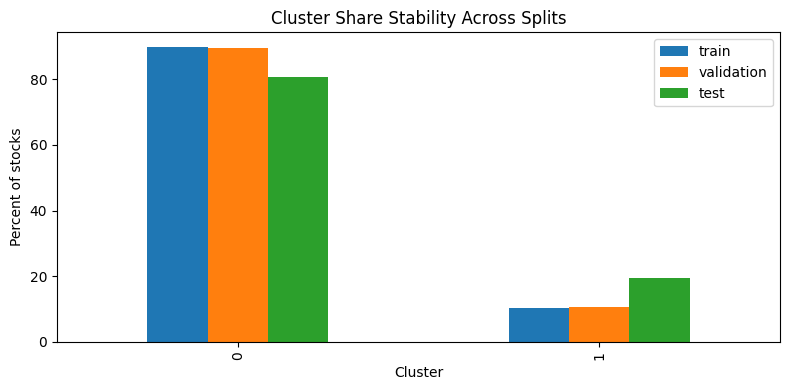

Train cluster feature means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0069,0.0169,0.0033
1,-0.0011,0.0319,0.0068


Validation cluster feature means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0076,0.0155,0.0187
1,-0.0019,0.0309,0.0486


Test cluster feature means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0104,0.0174,0.0006
1,0.0039,0.0304,0.0104


Validation minus train cluster means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0007,-0.0014,0.0153
1,-0.0008,-0.0010,0.0418


Test minus train cluster means


,logret_21,logvol_21,vol_chg_21
Cluster,,,
0,0.0034,0.0004,-0.0027
1,0.0051,-0.0015,0.0036


In [ ]:
# Cluster size stability across train/validation/test
cluster_dist = pd.concat([
    train_clusters["Cluster_train"].value_counts(normalize=True).sort_index().rename("train"),
    val_clusters["Cluster_val"].value_counts(normalize=True).sort_index().rename("validation"),
    test_clusters["Cluster_test"].value_counts(normalize=True).sort_index().rename("test")
], axis=1).fillna(0)

print("Cluster share by split (%)")
display((cluster_dist * 100).round(2))

ax = (cluster_dist * 100).plot(kind="bar", figsize=(8, 4))
ax.set_title("Cluster Share Stability Across Splits")
ax.set_xlabel("Cluster")
ax.set_ylabel("Percent of stocks")
plt.tight_layout()
plt.show()

# Feature drift check: cluster means by split
train_means = X_train.assign(Cluster=train_labels).groupby("Cluster")[best_features].mean()
val_means = X_val.assign(Cluster=val_labels).groupby("Cluster")[best_features].mean()
test_means = X_test.assign(Cluster=test_labels).groupby("Cluster")[best_features].mean()

print("Train cluster feature means")
display(train_means.round(4))

print("Validation cluster feature means")
display(val_means.round(4))

print("Test cluster feature means")
display(test_means.round(4))

common_val = train_means.index.intersection(val_means.index)
common_test = train_means.index.intersection(test_means.index)

if len(common_val) > 0:
    print("Validation minus train cluster means")
    display((val_means.loc[common_val] - train_means.loc[common_val]).round(4))

if len(common_test) > 0:
    print("Test minus train cluster means")
    display((test_means.loc[common_test] - train_means.loc[common_test]).round(4))


## 26. Name the Clusters + Stock Examples


In [ ]:
# Give human-readable names using volatility level
vol_cols = [c for c in best_features if c.startswith("logvol_")]
name_map = {}

if len(vol_cols) > 0 and cluster_profile_mean.shape[0] >= 2:
    vol_col = vol_cols[0]
    ordered = cluster_profile_mean[vol_col].sort_values()
    low_cluster = ordered.index[0]
    high_cluster = ordered.index[-1]

    name_map[low_cluster] = "Lower-vol / steadier"
    name_map[high_cluster] = "Higher-vol / more active"

for c in sorted(set(train_clusters["Cluster_train"])):
    name_map.setdefault(c, f"Cluster {c}")

train_clusters_named = train_clusters.copy()
train_clusters_named["Cluster_name"] = train_clusters_named["Cluster_train"].map(name_map)

print("Cluster naming map")
print(name_map)

cluster_sizes = train_clusters_named["Cluster_name"].value_counts().rename_axis("Cluster_name").reset_index(name="n_stocks")
print("Cluster sizes")
display(cluster_sizes)

stock_examples = (
    train_clusters_named.sort_values(["Cluster_name", "Symbol"])
    .groupby("Cluster_name")["Symbol"]
    .apply(lambda s: ", ".join(s.head(25)))
    .to_frame("example_symbols_first_25")
)

print("Stock examples by cluster")
display(stock_examples)


Cluster naming map
{np.int32(0): 'Lower-vol / steadier', np.int32(1): 'Higher-vol / more active'}
Cluster sizes


,Cluster_name,n_stocks
0,Lower-vol / steadier,448
1,Higher-vol / more active,51


Stock examples by cluster


,example_symbols_first_25
Cluster_name,
Higher-vol / more active,"ABNB, ALB, ALGN, AMD, APA, APP, AXON, BIIB, CC..."
Lower-vol / steadier,"A, AAPL, ABBV, ABT, ACGL, ACN, ADBE, ADI, ADM,..."
